# Task 1

---

## Web scraping and analysis

This Jupyter notebook includes some code to get you started with web scraping. We will use a package called `BeautifulSoup` to collect the data from the web. Once you've collected your data and saved it into a local `.csv` file you should start with your analysis.

### Scraping data from Skytrax

If you visit [https://www.airlinequality.com] you can see that there is a lot of data there. For this task, we are only interested in reviews related to British Airways and the Airline itself.

If you navigate to this link: [https://www.airlinequality.com/airline-reviews/british-airways] you will see this data. Now, we can use `Python` and `BeautifulSoup` to collect all the links to the reviews and then to collect the text data on each of the individual review links.

In [26]:
# Import necessary libraries
import pandas as pd
import re
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
import requests

import requests
from bs4 import BeautifulSoup

from collections import Counter

In [27]:
base_url = "https://www.airlinequality.com/airline-reviews/british-airways"
pages = 10
page_size = 100

reviews = []

# for i in range(1, pages + 1):
for i in range(1, pages + 1):

    print(f"Scraping page {i}")

    # Create URL to collect links from paginated data
    url = f"{base_url}/page/{i}/?sortby=post_date%3ADesc&pagesize={page_size}"

    # Collect HTML data from this page
    response = requests.get(url)

    # Parse content
    content = response.content
    parsed_content = BeautifulSoup(content, 'html.parser')
    for para in parsed_content.find_all("div", {"class": "text_content"}):
        reviews.append(para.get_text())

    print(f"   ---> {len(reviews)} total reviews")

Scraping page 1
   ---> 100 total reviews
Scraping page 2
   ---> 200 total reviews
Scraping page 3
   ---> 300 total reviews
Scraping page 4
   ---> 400 total reviews
Scraping page 5
   ---> 500 total reviews
Scraping page 6
   ---> 600 total reviews
Scraping page 7
   ---> 700 total reviews
Scraping page 8
   ---> 800 total reviews
Scraping page 9
   ---> 900 total reviews
Scraping page 10
   ---> 1000 total reviews


In [28]:
df = pd.DataFrame()
df["reviews"] = reviews
df.head()

,reviews
0,✅ Trip Verified | I had an appalling experie...
1,"Not Verified | Good points, the cabin crew, t..."
2,"Not Verified | It was a decent flight, reason..."
3,✅ Trip Verified | I really like flying Briti...
4,✅ Trip Verified | Could not book online the ...


In [29]:
df.to_csv("BA_reviews.csv")

Congratulations! Now you have your dataset for this task! The loops above collected 1000 reviews by iterating through the paginated pages on the website. However, if you want to collect more data, try increasing the number of pages!

 The next thing that you should do is clean this data to remove any unnecessary text from each of the rows. For example, "✅ Trip Verified" can be removed from each row if it exists, as it's not relevant to what we want to investigate.

In [30]:
# Download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
# Load the dataset
df = pd.read_csv("BA_reviews.csv")


# Cleaning (Data Wragling)

In [32]:
# Step 1: Remove unnecessary text
df['reviews'] = df['reviews'].str.replace("✅ Trip Verified", "", regex=False)

# Step 2: Handle missing data
df.dropna(subset=['reviews'], inplace=True)

In [33]:
# Step 3: Text preprocessing
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = ' '.join(word for word in text.split() if word not in stop_words)  # Remove stopwords
    return text

df['cleaned_reviews'] = df['reviews'].apply(clean_text)

In [34]:
# Step 4: Sentiment analysis
def analyze_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['polarity', 'subjectivity']] = df['cleaned_reviews'].apply(lambda x: pd.Series(analyze_sentiment(x)))

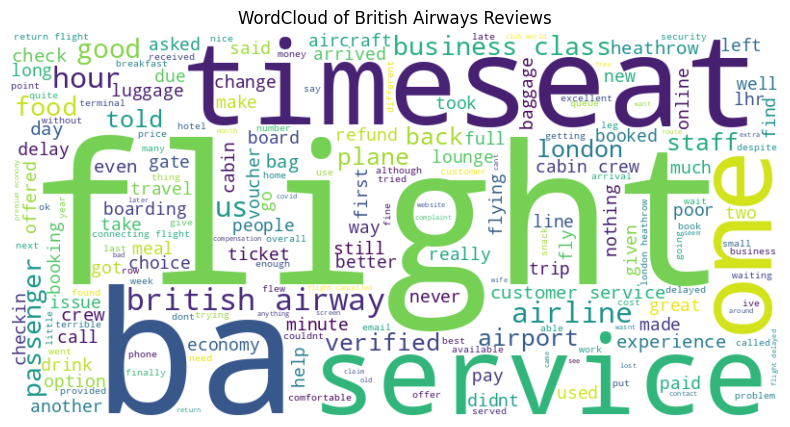

In [35]:
# Step 5: Generate WordCloud
all_words = ' '.join(df['cleaned_reviews'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of British Airways Reviews")
plt.show()

In [36]:
# Step 6: Save cleaned data
df.to_csv("BA_reviews_cleaned.csv", index=False)

# Display the first few rows of the cleaned dataset
df.head()

,Unnamed: 0,reviews,cleaned_reviews,polarity,subjectivity
0,0,| I had an appalling experience with Britis...,appalling experience british airways started t...,-0.058171,0.353734
1,1,"Not Verified | Good points, the cabin crew, t...",verified good points cabin crew helpful profes...,0.047050,0.490787
2,2,"Not Verified | It was a decent flight, reason...",verified decent flight reasonable comfortable ...,0.245022,0.632684
3,3,| I really like flying British Airways part...,really like flying british airways particularl...,0.236645,0.465087
4,4,| Could not book online the night before be...,could book online night system arrived early a...,-0.150000,0.300000


In [37]:
df.head(500)

,Unnamed: 0,reviews,cleaned_reviews,polarity,subjectivity
0,0,| I had an appalling experience with Britis...,appalling experience british airways started t...,-0.058171,0.353734
1,1,"Not Verified | Good points, the cabin crew, t...",verified good points cabin crew helpful profes...,0.047050,0.490787
2,2,"Not Verified | It was a decent flight, reason...",verified decent flight reasonable comfortable ...,0.245022,0.632684
3,3,| I really like flying British Airways part...,really like flying british airways particularl...,0.236645,0.465087
4,4,| Could not book online the night before be...,could book online night system arrived early a...,-0.150000,0.300000
...,...,...,...,...,...
495,495,| Old A320 with narrow pitch. Flight perfect...,old narrow pitch flight perfectly time constan...,0.286905,0.533333
496,496,| Another BA Shambles. Started off well with...,another ba shambles started well excellent che...,0.180952,0.583333
497,497,Not Verified | BA cancelled my flight home to...,verified ba cancelled flight home heathrow dec...,-0.278571,0.480952
498,498,"Not Verified | BA cancelled my flight home, t...",verified ba cancelled flight home last flight ...,-0.012500,0.329167


In [38]:
# Analyze key and major words
all_words = ' '.join(df['cleaned_reviews']).split()
word_counts = Counter(all_words)
most_common_words = word_counts.most_common(20)


In [39]:
# Display the most common words
print("Most Common Words:")
for word, count in most_common_words:
    print(f"{word}: {count}")


Most Common Words:
flight: 1977
ba: 1315
service: 732
time: 541
crew: 456
british: 447
seat: 443
london: 442
us: 440
food: 438
airways: 427
one: 427
good: 426
class: 425
would: 406
business: 403
get: 390
staff: 385
seats: 379
hours: 373


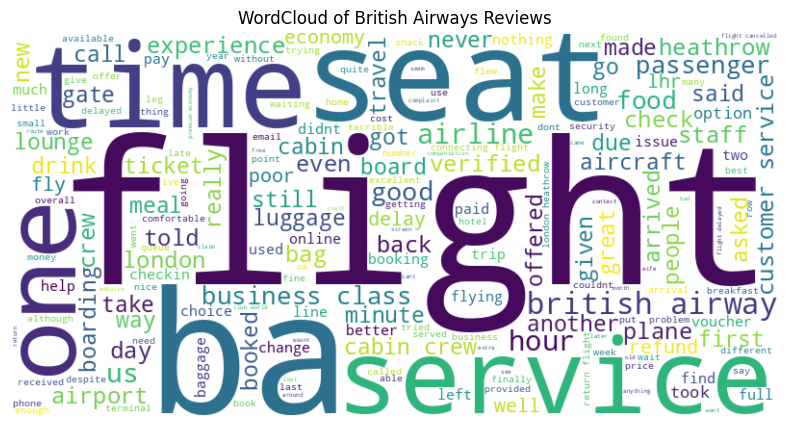

In [40]:
# Step 2: Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of British Airways Reviews")
plt.show()

In [41]:

# Step 3: Analyze polarity and subjectivity
# Summary statistics for polarity and subjectivity
polarity_mean = df['polarity'].mean()
subjectivity_mean = df['subjectivity'].mean()

print(f"\nAverage Polarity: {polarity_mean:.2f} (Range: -1 to 1, where -1 is negative, 1 is positive)")
print(f"Average Subjectivity: {subjectivity_mean:.2f} (Range: 0 to 1, where 0 is fact, 1 is opinion)")


Average Polarity: 0.06 (Range: -1 to 1, where -1 is negative, 1 is positive)
Average Subjectivity: 0.48 (Range: 0 to 1, where 0 is fact, 1 is opinion)


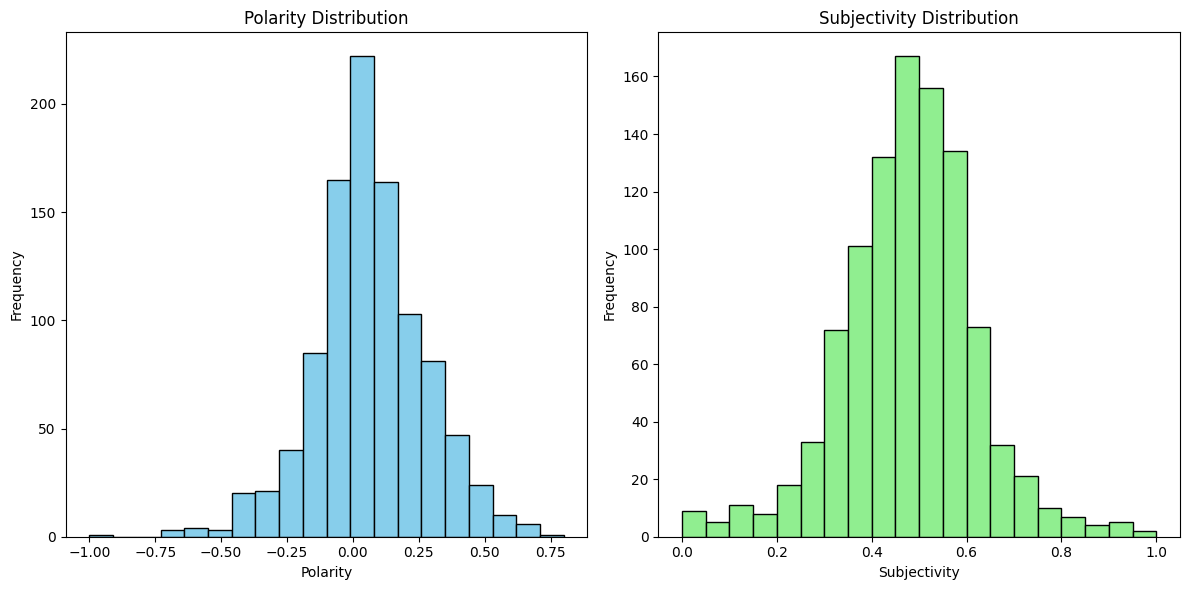

In [42]:

# Visualize polarity and subjectivity
plt.figure(figsize=(12, 6))

# Polarity distribution
plt.subplot(1, 2, 1)
plt.hist(df['polarity'], bins=20, color='skyblue', edgecolor='black')
plt.title("Polarity Distribution")
plt.xlabel("Polarity")
plt.ylabel("Frequency")

# Subjectivity distribution
plt.subplot(1, 2, 2)
plt.hist(df['subjectivity'], bins=20, color='lightgreen', edgecolor='black')
plt.title("Subjectivity Distribution")
plt.xlabel("Subjectivity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Here is the code to analyze the key and major words in the reviews, generate a WordCloud, and analyze the polarity and subjectivity of the reviews:

### Explanation:
1. **Key and Major Words**:
   - The `Counter` class is used to count the frequency of words in the cleaned reviews.
   - The top 20 most common words are displayed.

2. **WordCloud**:
   - A WordCloud is generated to visualize the most frequent words in the reviews.

3. **Polarity and Subjectivity**:
   - The average polarity and subjectivity are calculated to understand the overall sentiment of the reviews.
   - Histograms are plotted to visualize the distribution of polarity and subjectivity.

### Insights:
- **Polarity**: Indicates whether the reviews are generally positive, negative, or neutral.
- **Subjectivity**: Shows whether the reviews are more opinion-based or fact-based.
- **WordCloud**: Highlights the most frequently mentioned words, which can provide insights into common themes or issues in the reviews.

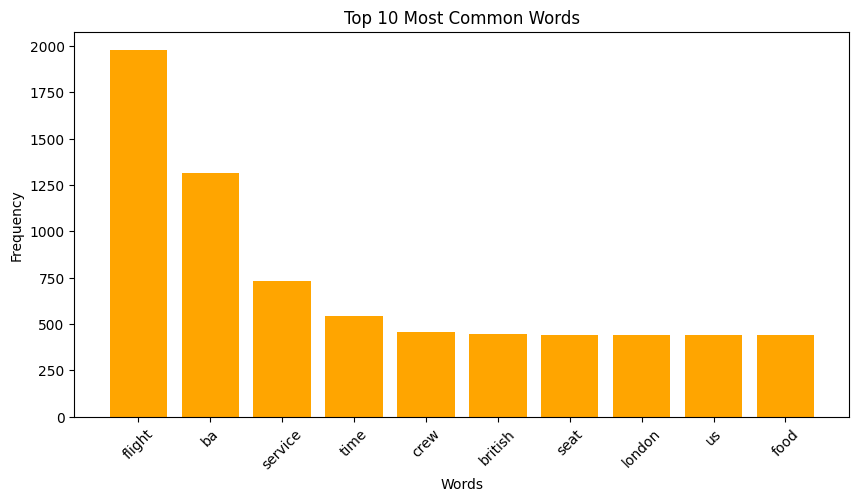

In [43]:
# 3. Word Frequency (Top 10 Words)
all_words = ' '.join(df['cleaned_reviews']).split()
word_counts = Counter(all_words)
most_common_words = word_counts.most_common(10)

words, counts = zip(*most_common_words)
plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='orange')
plt.title("Top 10 Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

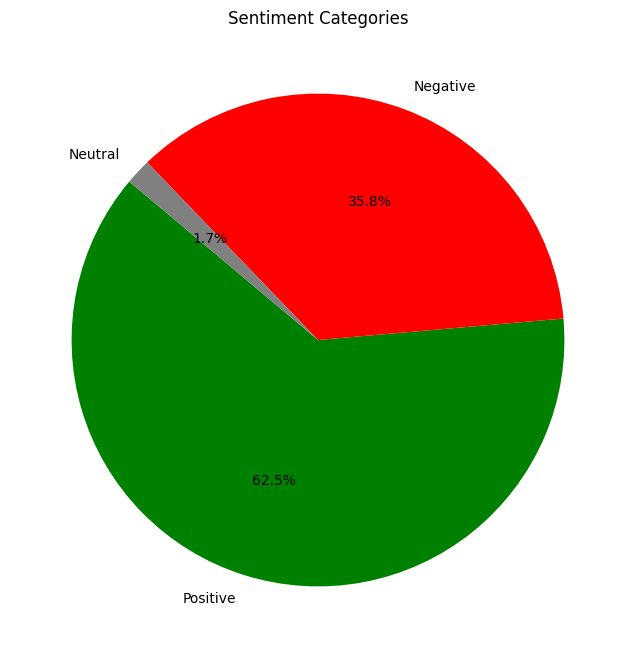

In [44]:
# 4. Sentiment Categories (Positive, Neutral, Negative)
def categorize_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment_category'] = df['polarity'].apply(categorize_sentiment)
sentiment_counts = df['sentiment_category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['green', 'red', 'gray'])
plt.title("Sentiment Categories")
plt.show()

# Explanation:

1. Polarity Distribution: Shows how reviews are distributed across positive, negative, and neutral sentiments.

2. Subjectivity Distribution: Highlights whether reviews are more opinion-based or fact-based.
Word Frequency: Displays the top 10 most common words in the reviews.

3. Sentiment Categories: Categorizes reviews into positive, neutral, and negative sentiments and visualizes them as a pie chart.

These visualizations provide insights into customer sentiment and common themes in the reviews, which can be used for business decision-making.